# Step 3: Using SAM 2

**Segment Anything 2 (SAM 2)** is a powerful segmentation model released in July 2024 that pushes the boundaries of image and video segmentation. It brings new capabilities to computer vision applications, including the ability to generate precise masks and track objects across frames in videos using just simple prompts.

In this notebook, you'll learn how to:
- Understand the key innovations in SAM 2
- Apply SAM 2 to image datasets using bounding boxes, keypoints, or no prompts at all
- Leverage SAM 2’s video segmentation and mask tracking capabilities with a single-frame prompt


## What is SAM 2?

SAM 2 is the next generation of the Segment Anything Model, originally introduced by Meta in 2023. While SAM was designed for zero-shot segmentation on still images, SAM 2 adds robust video segmentation and tracking capabilities. With just a bounding box or a set of keypoints on a single frame, SAM 2 can segment and track objects across entire video sequences.

## Using SAM 2 for Images

SAM 2 integrates directly with the FiftyOne Model Zoo, allowing you to apply segmentation to image datasets with minimal code. Whether you're working with ground truth bounding boxes, keypoints, or want to explore automatic mask generation, FiftyOne makes the process seamless.

In [7]:
%%capture
!pip install -U fiftyone sam2

In [2]:
import fiftyone as fo
import fiftyone.zoo as foz

# Load dataset

# dataset = foz.load_zoo_dataset("quickstart", max_samples=25, shuffle=True, seed=51)
dataset = fo.load_dataset("construction-ppe").limit(10)
# Load SAM 2 image model
model = foz.load_zoo_model("segment-anything-2-hiera-tiny-image-torch")

# Prompt with bounding boxes
dataset.apply_model(model, label_field="segmentations", prompt_field="YOLOv8")

# Launch app to view segmentations
session = fo.launch_app(dataset)

/opt/app-root/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PackageError: The requested operation requires that 'torch' is installed on your machine.

If you think this error is inaccurate, you can set `fiftyone.config.requirement_error_level` to 1 (warning) or 2 (ignore).
See https://docs.voxel51.com/user_guide/config.html for details.

## Keypoints with SAM2

### Prompting with Keypoints

Keypoint prompts are a great alternative to bounding boxes when working with articulated objects like people. Here, we filter images to include only people, generate keypoints using a keypoint model, and then use those keypoints to prompt SAM 2 for segmentation.

In [3]:
import fiftyone as fo
import fiftyone.zoo as foz
from fiftyone import ViewField as F

dataset = fo.load_dataset("construction-ppe").limit(10)

# Filter persons only
dataset = dataset.filter_labels("YOLOv8", F("label") == "person")

# Apply keypoint detection
kp_model = foz.load_zoo_model("keypoint-rcnn-resnet50-fpn-coco-torch")
dataset.default_skeleton = kp_model.skeleton
dataset.apply_model(kp_model, label_field="gt_keypoints")

 100% |███████████████████| 10/10 [54.8s elapsed, 0s remaining, 0.2 samples/s]    


In [4]:
session = fo.launch_app(dataset)

INFO:fiftyone.core.models:Downloading model from 'https://download.pytorch.org/models/keypointrcnn_resnet50_fpn_coco-fc266e95.pth'...


 100% |██████|    1.8Gb/1.8Gb [39.2s elapsed, 0s remaining, 43.4Mb/s]      


INFO:eta.core.utils: 100% |██████|    1.8Gb/1.8Gb [39.2s elapsed, 0s remaining, 43.4Mb/s]      
Downloading: "https://download.pytorch.org/models/keypointrcnn_resnet50_fpn_coco-fc266e95.pth" to /Users/hassanbadawy/.cache/torch/hub/checkpoints/keypointrcnn_resnet50_fpn_coco-fc266e95.pth
100%|██████████| 226M/226M [00:36<00:00, 6.56MB/s] 


 100% |█████████████████| 100/100 [1.3m elapsed, 0s remaining, 1.3 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 100/100 [1.3m elapsed, 0s remaining, 1.3 samples/s]      



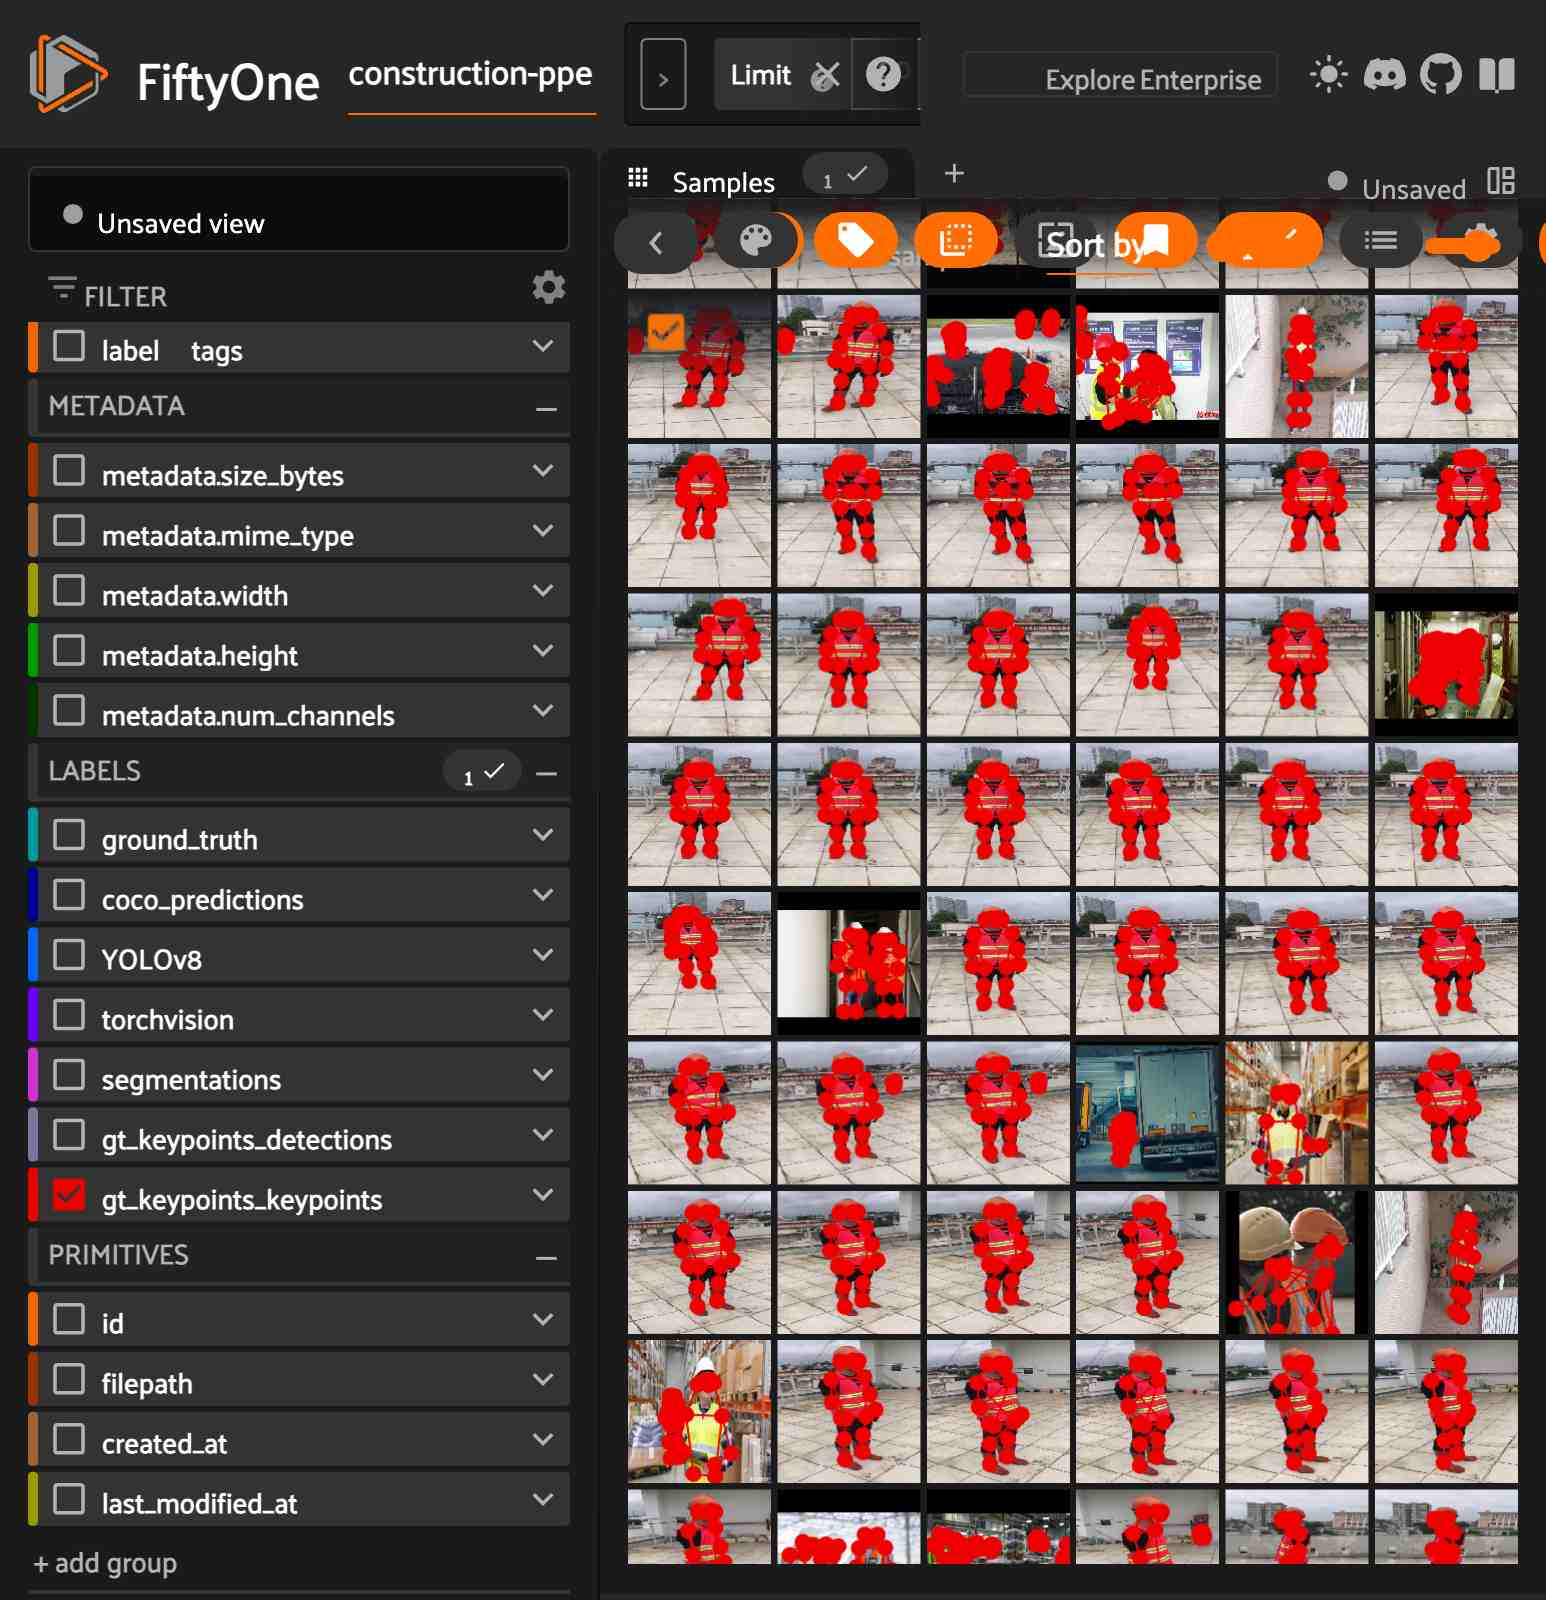

In [7]:
session.show()

 100% |█████████████████| 100/100 [1.5m elapsed, 0s remaining, 1.1 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 100/100 [1.5m elapsed, 0s remaining, 1.1 samples/s]      



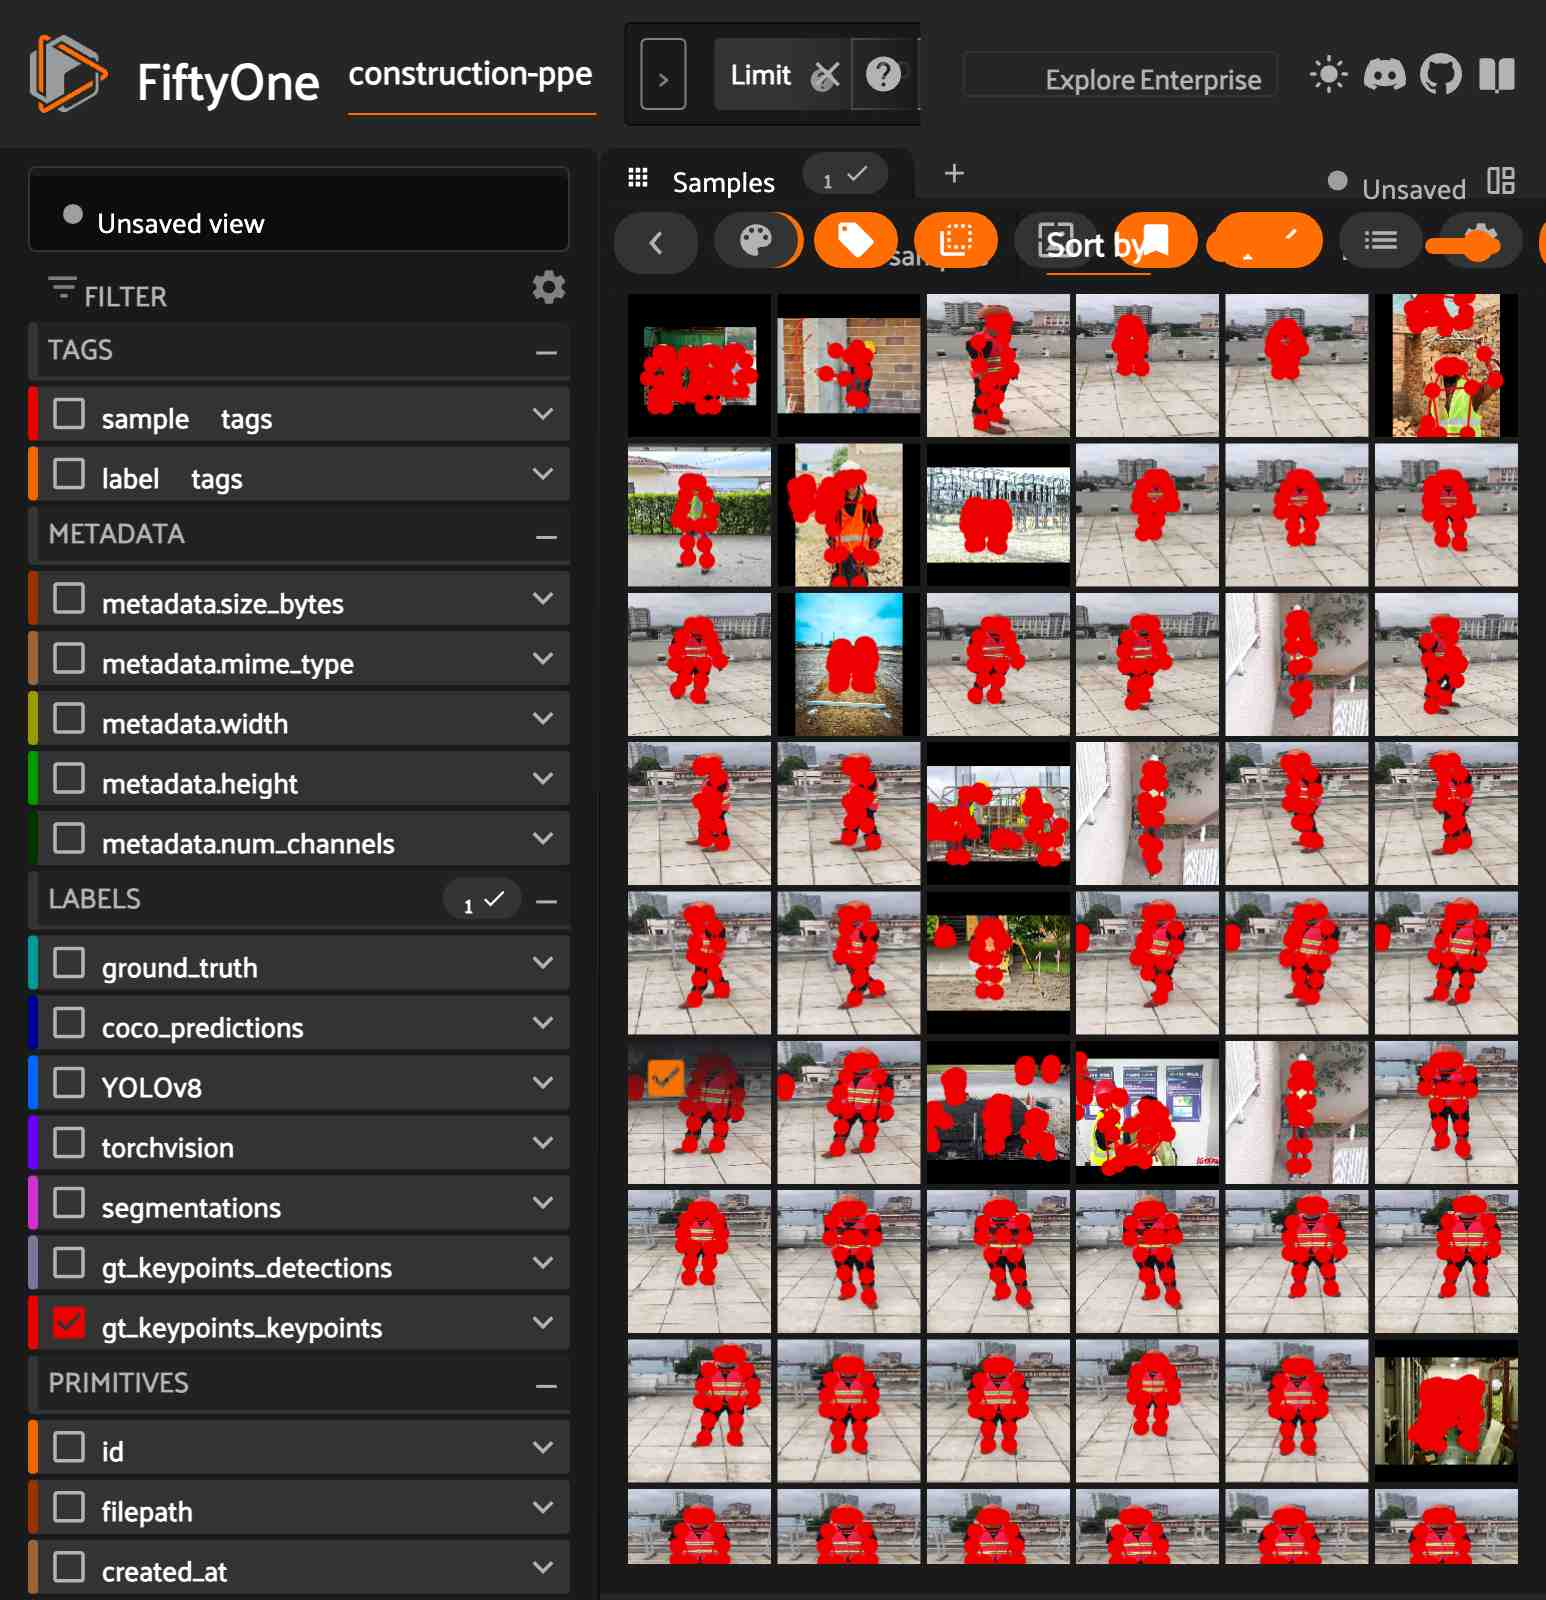

In [ ]:
# Apply SAM 2 with keypoints
model = foz.load_zoo_model("segment-anything-2-hiera-tiny-image-torch")
dataset.apply_model(model, label_field="segmentations", prompt_field="gt_keypoints_keypoints")
session.show()

## Using SAM 2 for Video

SAM 2 brings game-changing capabilities to video understanding. It can track segmentations across frames from a single bounding box or keypoint prompt provided on the first frame. With this, you can propagate high-quality segmentation masks through entire sequences automatically.

In [8]:
dataset = foz.load_zoo_dataset("quickstart-video", max_samples=2)
from fiftyone import ViewField as F

# Remove boxes after first frame
(
    dataset
    .match_frames(F("frame_number") > 1)
    .set_field("frames.detections", None)
    .save()
)
session = fo.launch_app(dataset)

Dataset already downloaded
Loading existing dataset 'quickstart-video-2'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [6]:
# Apply video model with first-frame prompt
model = foz.load_zoo_model("segment-anything-2-hiera-tiny-video-torch")
dataset.apply_model(model, label_field="segmentations", prompt_field="frames.detections")
session = fo.launch_app(dataset)

 100% |██████|    1.2Gb/1.2Gb [1.7s elapsed, 0s remaining, 833.1Mb/s]          


PackageError: The requested operation requires that 'sam2' is installed on your machine.

If you think this error is inaccurate, you can set `fiftyone.config.requirement_error_level` to 1 (warning) or 2 (ignore).
See https://docs.voxel51.com/user_guide/config.html for details.

![sam2_video](https://cdn.voxel51.com/getting_started_segmentation/notebook3/sam2_video.webp)

## Available SAM 2 Models in FiftyOne

**Image Models:**
- `segment-anything-2-hiera-tiny-image-torch`
- `segment-anything-2-hiera-small-image-torch`
- `segment-anything-2-hiera-base-plus-image-torch`
- `segment-anything-2-hiera-large-image-torch`

**Video Models:**
- `segment-anything-2-hiera-tiny-video-torch`
- `segment-anything-2-hiera-small-video-torch`
- `segment-anything-2-hiera-base-plus-video-torch`
- `segment-anything-2-hiera-large-video-torch`